## To train ANN on the processed data for churn

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

In [2]:
data = pd.read_csv('../Data/processed_customer_churn.csv')

In [3]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,Credit card (automatic),Electronic check,Mailed check
0,0,0,1,0,1.0,0,0,1,0,1,...,0,0,0,1,29.85,3.396185,0,False,True,False
1,1,0,0,0,34.0,1,0,1,1,0,...,0,0,1,0,56.95,7.544068,0,False,False,True
2,1,0,0,0,2.0,1,0,1,1,1,...,0,0,0,1,53.85,4.683519,1,False,False,True
3,1,0,0,0,45.0,0,0,1,1,0,...,0,0,1,0,42.30,7.517928,0,False,False,False
4,0,0,0,0,2.0,1,0,2,0,0,...,0,0,0,1,70.70,5.021575,1,False,True,False


In [4]:
X = data.drop('Churn', axis= 1)
y = data['Churn']

In [5]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X = sc.fit_transform(X)

### traintest split

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, stratify= y, random_state= 0)

print(y_train.value_counts())
print(y_test.value_counts())

Churn
0    4139
1    1495
Name: count, dtype: int64
Churn
0    1035
1     374
Name: count, dtype: int64


## Now we train the model

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Define the model
class ANNModel(nn.Module):
    def __init__(self):
        super(ANNModel, self).__init__()
        self.fc1 = nn.Linear(21, 16)
        self.fc2 = nn.Linear(16, out_features=8)
        self.output = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.sigmoid(self.output(x))
        return x


In [22]:
model = ANNModel()

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

# Create datasets for training and validation
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_dataloader = DataLoader(train_dataset, batch_size=100, shuffle=True)

# For validation, we'll use the test set (or you can create a separate validation split)
val_dataset = TensorDataset(X_test_tensor, y_test_tensor)
val_dataloader = DataLoader(val_dataset, batch_size=100, shuffle=False)

# Lists to track losses
train_losses = []
val_losses = []

EPOCHS = 10
for epoch in range(EPOCHS):
    # Training phase
    model.train()
    train_loss = 0.0
    for batch_X, batch_y in train_dataloader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in val_dataloader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
    
    # Calculate average losses
    avg_train_loss = train_loss / len(train_dataloader)
    avg_val_loss = val_loss / len(val_dataloader)
    
    # Store losses
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

Epoch 1/10, Train Loss: 0.7197, Val Loss: 0.6697
Epoch 2/10, Train Loss: 0.6024, Val Loss: 0.5251
Epoch 3/10, Train Loss: 0.4852, Val Loss: 0.4413
Epoch 4/10, Train Loss: 0.4426, Val Loss: 0.4200
Epoch 3/10, Train Loss: 0.4852, Val Loss: 0.4413
Epoch 4/10, Train Loss: 0.4426, Val Loss: 0.4200
Epoch 5/10, Train Loss: 0.4285, Val Loss: 0.4111
Epoch 6/10, Train Loss: 0.4203, Val Loss: 0.4064
Epoch 7/10, Train Loss: 0.4192, Val Loss: 0.4044
Epoch 5/10, Train Loss: 0.4285, Val Loss: 0.4111
Epoch 6/10, Train Loss: 0.4203, Val Loss: 0.4064
Epoch 7/10, Train Loss: 0.4192, Val Loss: 0.4044
Epoch 8/10, Train Loss: 0.4115, Val Loss: 0.4032
Epoch 9/10, Train Loss: 0.4106, Val Loss: 0.4017
Epoch 10/10, Train Loss: 0.4089, Val Loss: 0.4011
Epoch 8/10, Train Loss: 0.4115, Val Loss: 0.4032
Epoch 9/10, Train Loss: 0.4106, Val Loss: 0.4017
Epoch 10/10, Train Loss: 0.4089, Val Loss: 0.4011


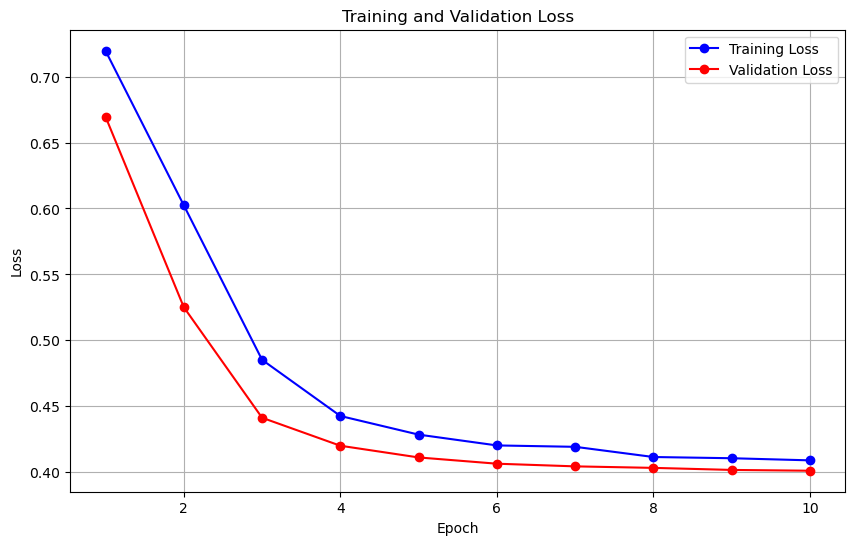

In [29]:
plt.figure(figsize=(10, 6))

epochs = range(1, EPOCHS + 1)

plt.plot(epochs, train_losses, 'b-o', label="Training Loss")
plt.plot(epochs, val_losses, 'r-o', label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

## Model Evaluation on Test Data

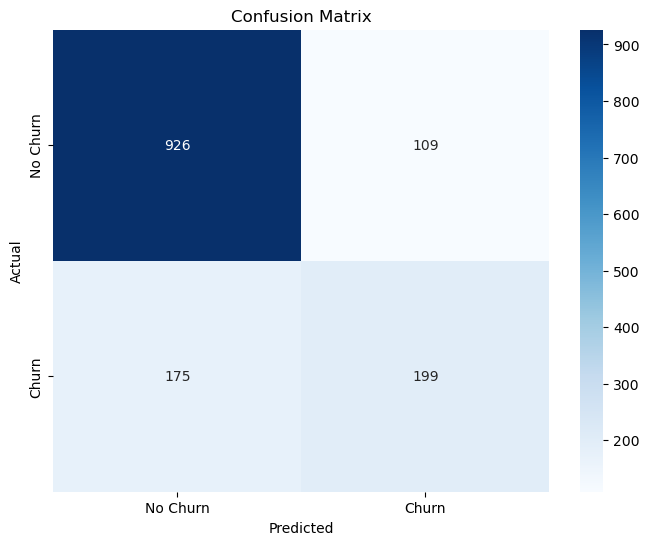

              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.87      1035
       Churn       0.65      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [27]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    test_predictions = (test_outputs > 0.5).float()

y_test_np = y_test.values
y_pred_np = test_predictions.numpy().flatten()

cm = confusion_matrix(y_test_np, y_pred_np)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'], 
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(classification_report(y_test_np, y_pred_np, target_names=['No Churn', 'Churn']))

### Integrating SHAP

In [47]:
import shap

model.eval()

background_size = 100
np.random.seed(42)  
background_indices = np.random.choice(len(X_train), background_size, replace=False)
background_data = torch.tensor(X_train[background_indices], dtype=torch.float32)

explainer = shap.DeepExplainer(model, background_data)

In [48]:
test_samples = torch.tensor(X_test[:10], dtype=torch.float32)

shap_values = explainer.shap_values(test_samples, check_additivity=False)

print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (10, 21, 1)


In [49]:
original_data = pd.read_csv('../Data/processed_customer_churn.csv')
feature_names = original_data.drop('Churn', axis=1).columns.tolist()

print(f"Feature names: {feature_names}")
print(f"no. of features: {len(feature_names)}")

Feature names: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Credit card (automatic)', 'Electronic check', 'Mailed check']
no. of features: 21


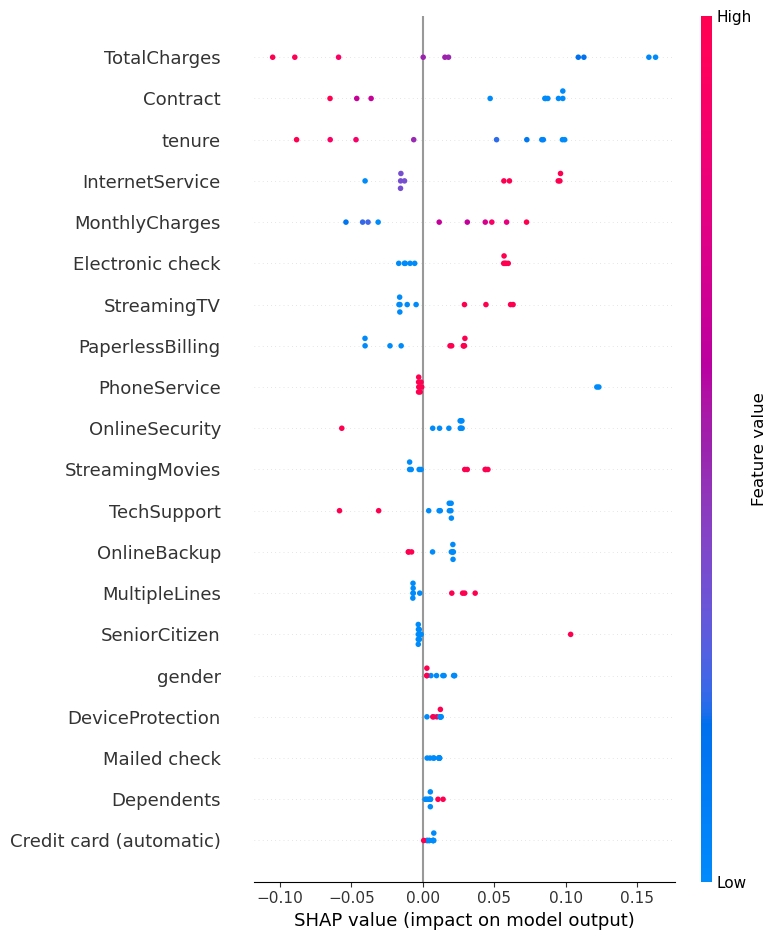

In [53]:
shap_values_reshaped = shap_values.squeeze(-1)

shap.summary_plot(shap_values_reshaped, test_samples.numpy(), feature_names=feature_names, rng=True)

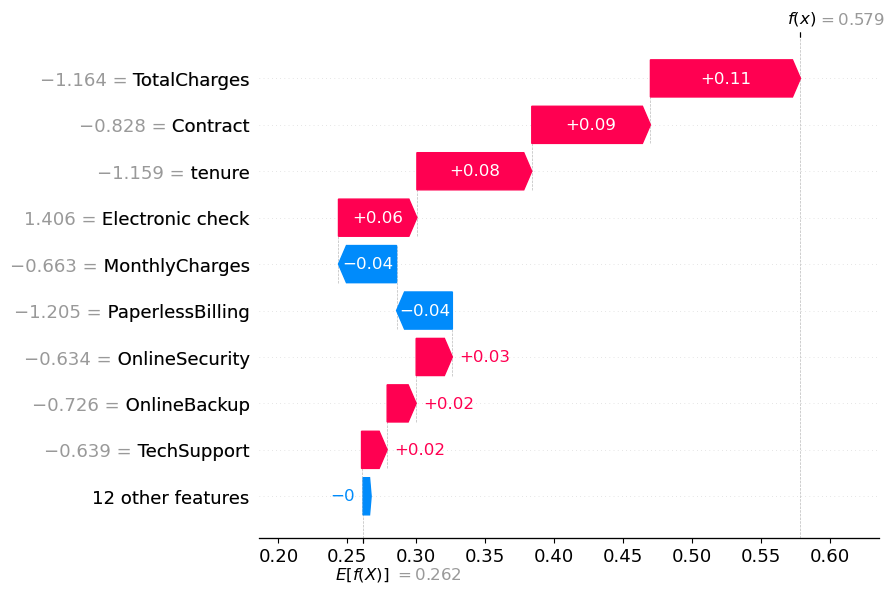

In [57]:
sample_idx = 1
expected_value = explainer.expected_value

explanation = shap.Explanation(
    values=shap_values_reshaped[sample_idx], 
    base_values=expected_value, 
    data=test_samples[sample_idx].numpy(),
    feature_names=feature_names
)

shap.waterfall_plot(explanation)

In [54]:
print(expected_value)

[0.2615093]


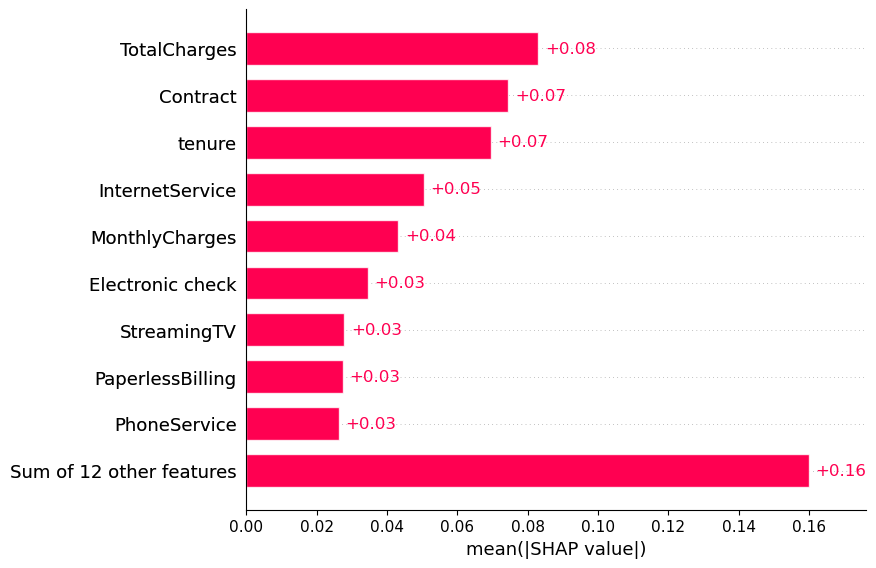

In [58]:
explanation_all = shap.Explanation(
    values=shap_values_reshaped, 
    base_values=explainer.expected_value, 
    data=test_samples.numpy(),
    feature_names=feature_names
)

shap.plots.bar(explanation_all)

### Individual prediction and what pushed it

In [59]:
# Show individual predictions and their explanations
model.eval()
with torch.no_grad():
    predictions = model(test_samples)

print("Individual Predictions and SHAP Explanations:")
print("=" * 50)

for i in range(min(5, len(test_samples))):  # Show first 5 samples
    pred_prob = predictions[i].item()
    pred_class = "Churn" if pred_prob > 0.5 else "No Churn"
    actual_class = "Churn" if y_test.iloc[i] == 1 else "No Churn"
    
    print(f"\nSample {i+1}:")
    print(f"  Predicted: {pred_class} (probability: {pred_prob:.3f})")
    print(f"  Actual: {actual_class}")
    print(f"  Top 3 most important features:")
    
    # Get top 3 features by absolute SHAP value
    shap_vals_sample = shap_values_reshaped[i]
    feature_importance = list(zip(feature_names, shap_vals_sample))
    feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)
    
    for j, (feature, shap_val) in enumerate(feature_importance[:3]):
        direction = "increases" if shap_val > 0 else "decreases"
        print(f"    {j+1}. {feature}: {float(shap_val):.4f} ({direction} churn probability)")

Individual Predictions and SHAP Explanations:

Sample 1:
  Predicted: No Churn (probability: 0.010)
  Actual: No Churn
  Top 3 most important features:
    1. Contract: -0.0650 (decreases churn probability)
    2. InternetService: -0.0404 (decreases churn probability)
    3. MonthlyCharges: -0.0313 (decreases churn probability)

Sample 2:
  Predicted: Churn (probability: 0.501)
  Actual: No Churn
  Top 3 most important features:
    1. TotalCharges: 0.1089 (increases churn probability)
    2. Contract: 0.0861 (increases churn probability)
    3. tenure: 0.0834 (increases churn probability)

Sample 3:
  Predicted: Churn (probability: 0.814)
  Actual: Churn
  Top 3 most important features:
    1. TotalCharges: 0.1630 (increases churn probability)
    2. SeniorCitizen: 0.1035 (increases churn probability)
    3. Contract: 0.0980 (increases churn probability)

Sample 4:
  Predicted: No Churn (probability: 0.155)
  Actual: Churn
  Top 3 most important features:
    1. TotalCharges: -0.0897 